# Metient-evaluate

##### This tutorial is intended for those who want to run Metient in evaluate mode, and have Metient infer (1) the proportions of each clone in each anatomical site, and (2) the labeled clone tree. 

##### To run this notebook, you'll need metient installed (follow installation instructions on the github README)

### Import libraries and setup paths

In [1]:
import os
import metient as met
import warnings
warnings.filterwarnings('ignore')

### Setup paths
# Path to where our input clone trees and tsvs are located
notebook_dir = '/data1/morrisq/divyak/projects/metient/tutorial'
input_dir = os.path.join(notebook_dir, "inputs")
# Path to save outputs
output_dir = os.path.join(notebook_dir, "3_outputs")

### An example of the expected tsv file format for melanoma patient A
**The required columns are:**
`anatomical_site_index, anatomical_site_label, cluster_index, character_index, character_label, ref, var, var_read_prob, site_category` (see `../README.md` for description of each column)

In [2]:
import pandas as pd
df = pd.read_csv(os.path.join(input_dir, "A_SNVs.tsv"), sep="\t")
df

,anatomical_site_index,anatomical_site_label,cluster_index,character_index,character_label,ref,var,var_read_prob,site_category
0,0,"Primary, forehead",4,0,DYNC2H1,79,33,0.500,primary
1,1,Parotid metastasis,4,0,DYNC2H1,188,21,0.500,metastasis
2,2,"Locoregional skin metastasis 1, forehead",4,0,DYNC2H1,105,27,0.500,metastasis
3,3,"Locoregional skin metastasis 2, angle jaw",4,0,DYNC2H1,77,31,0.500,metastasis
4,0,"Primary, forehead",6,1,LPHN3,136,97,0.500,primary
...,...,...,...,...,...,...,...,...,...
535,3,"Locoregional skin metastasis 2, angle jaw",0,133,ROBO4,133,51,0.500,metastasis
536,0,"Primary, forehead",4,134,SHROOM3,102,58,0.500,primary
537,1,Parotid metastasis,4,134,SHROOM3,177,15,0.500,metastasis
538,2,"Locoregional skin metastasis 1, forehead",4,134,SHROOM3,112,29,0.500,metastasis


### If available, load organotropism frequencies

In [3]:
MSK_MET_FREQ_FILE = '/data1/morrisq/divyak/projects/metient/data/msk_met/msk_met_freq_by_cancer_type.csv'

MAPPINGS = [
	# Patient A
	{
		'Parotid metastasis':'Head and Neck',
		'Locoregional skin metastasis 1, forehead':'Skin',
		'Locoregional skin metastasis 2, angle jaw':'Skin',
	},
	# Patient B
	{
		'Lymph node metastasis, left axilla':'Distant LN',
		'Locoregional skin metastasis 1, left back':'Skin',
		'Locoregional skin metastasis 2, left axilla':'Skin',
	},
	# Patient C
	{
		'Locoregional skin metastasis 1, right calf':'Skin',
		'Locoregional skin metastasis 2, right mid-calf':'Skin',
	},
	# Patient D
	{
		'Locoregional skin metastasis 1, right ankle':'Skin',
		'Locoregional skin metastasis 2, right leg':'Skin',
		'Lymph node metastasis, right groin':'Distant LN',
	},
	# Patient E
	{
		'Locoregional skin metastasis 1, left heel':'Skin',
		'Locoregional skin metastasis 2, left heel':'Skin',
		'Locoregional skin metastasis 3, left heel':'Skin',
		'Lymph node metastasis, left groin':'Distant LN',
	},
	# Patient F
	{
		'Locoregional skin metastasis, left ear':'Skin',
		'Distant skin metastasis, back':'Skin',
		'Lymph node metastasis, left cervical node':'Distant LN',
	},
	# Patient G
	{
		'Lung metastasis':'Lung',
		'Locoregional skin metastasis, axilla':'Skin',
	},
]

def get_metastasis_frequencies(site_mappings, met_freq_file):
    """
    Returns list of dictionaries containing normalized frequencies for each patient's sites
    """
    met_freq_df = pd.read_csv(met_freq_file)
    melanoma_freq = met_freq_df[met_freq_df['Cancer Type'] == 'Melanoma']

    # Get frequencies for our site categories
    O_by_patient = []
    for mapping in site_mappings:
        O = {}
        for melanoma_site, msk_site in mapping.items():
            freq = float(melanoma_freq[msk_site].iloc[0])
            O[melanoma_site] = freq
			
        # Normalize frequencies
        total = sum(O.values())
        if total > 0:
            O = {k:v/total for k,v in O.items()}
        O_by_patient.append(O)
    return O_by_patient

Os = get_metastasis_frequencies(MAPPINGS, MSK_MET_FREQ_FILE)
print(Os)

[{'Parotid metastasis': 0.04500978473581213, 'Locoregional skin metastasis 1, forehead': 0.4774951076320939, 'Locoregional skin metastasis 2, angle jaw': 0.4774951076320939}, {'Lymph node metastasis, left axilla': 0.14685314685314685, 'Locoregional skin metastasis 1, left back': 0.42657342657342656, 'Locoregional skin metastasis 2, left axilla': 0.42657342657342656}, {'Locoregional skin metastasis 1, right calf': 0.5, 'Locoregional skin metastasis 2, right mid-calf': 0.5}, {'Locoregional skin metastasis 1, right ankle': 0.42657342657342656, 'Locoregional skin metastasis 2, right leg': 0.42657342657342656, 'Lymph node metastasis, right groin': 0.14685314685314685}, {'Locoregional skin metastasis 1, left heel': 0.29901960784313725, 'Locoregional skin metastasis 2, left heel': 0.29901960784313725, 'Locoregional skin metastasis 3, left heel': 0.29901960784313725, 'Lymph node metastasis, left groin': 0.10294117647058823}, {'Locoregional skin metastasis, left ear': 0.42657342657342656, 'Dist

## Step 1: Run Metient-evaluate on each Sanborn et al. melanoma patient individually
IMPORTANT: For the tutorial, we use default values for `sample_size` and `num_runs`. On your data, `sample_size` and `num_runs` should be set based on your input sizes. Please see our [full guide](https://github.com/morrislab/metient/tree/main/metient/docs/guide.md#performance-parameters) on how to set these values.

/data1/morrisq/divyak/projects/metient/tutorial/3_outputs/tmp_A_clustered_SNVs.tsv
Using organotropism frequencies {'Parotid metastasis': 0.04500978473581213, 'Locoregional skin metastasis 1, forehead': 0.4774951076320939, 'Locoregional skin metastasis 2, angle jaw': 0.4774951076320939}
Organotropism frequencies: tensor([0.00, 0.05, 0.48, 0.48])
Tumor samples: ['Primary, forehead', 'Parotid metastasis', 'Locoregional skin metastasis 1, forehead', 'Locoregional skin metastasis 2, angle jaw']
Input tree has 8 nodes.
/data1/morrisq/divyak/projects/metient/metient/lib


  3%|▎         | 126/4600 [00:02<00:39, 114.30it/s]

Number of fixed nodes: 2, number of unknown nodes: 6


100%|█████████▉| 4597/4600 [00:24<00:00, 199.20it/s]

Number of final solutions: 1
A_Primary, forehead


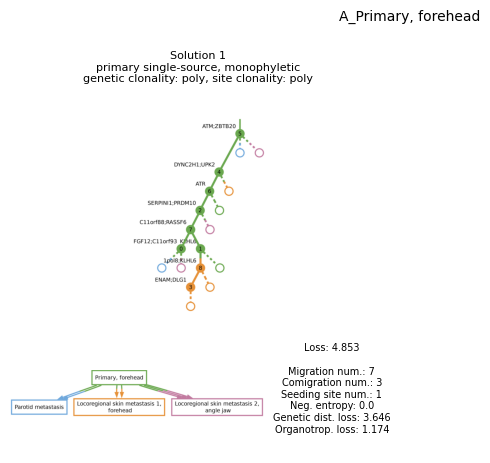

/data1/morrisq/divyak/projects/metient/tutorial/3_outputs/tmp_B_clustered_SNVs.tsv
Using organotropism frequencies {'Lymph node metastasis, left axilla': 0.14685314685314685, 'Locoregional skin metastasis 1, left back': 0.42657342657342656, 'Locoregional skin metastasis 2, left axilla': 0.42657342657342656}
Organotropism frequencies: tensor([0.00, 0.15, 0.43, 0.43])
Tumor samples: ['Primary, mid-left back', 'Lymph node metastasis, left axilla', 'Locoregional skin metastasis 1, left back', 'Locoregional skin metastasis 2, left axilla']
Input tree has 4 nodes.


  3%|▎         | 138/4600 [00:00<00:21, 204.62it/s]

Number of fixed nodes: 3, number of unknown nodes: 2


100%|█████████▉| 4596/4600 [00:20<00:00, 217.96it/s]

Number of final solutions: 1
B_Primary, mid-left back


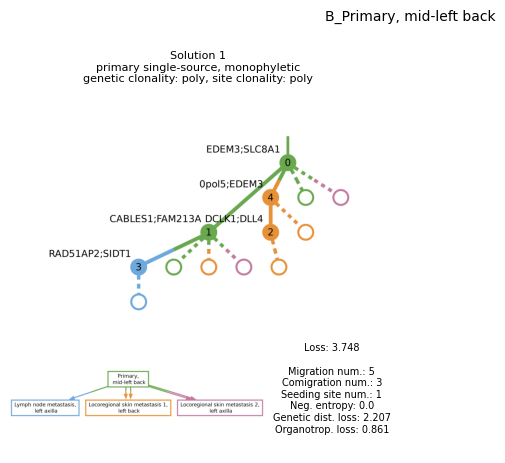

/data1/morrisq/divyak/projects/metient/tutorial/3_outputs/tmp_C_clustered_SNVs.tsv
Using organotropism frequencies {'Locoregional skin metastasis 1, right calf': 0.5, 'Locoregional skin metastasis 2, right mid-calf': 0.5}
Organotropism frequencies: tensor([0.00, 0.50, 0.50])
Tumor samples: ['Primary, right lower calf', 'Locoregional skin metastasis 1, right calf', 'Locoregional skin metastasis 2, right mid-calf']
Input tree has 7 nodes.


  3%|▎         | 121/4600 [00:00<00:23, 194.50it/s]

Number of fixed nodes: 1, number of unknown nodes: 6


100%|█████████▉| 4585/4600 [00:20<00:00, 219.25it/s]

Number of final solutions: 1
C_Primary, right lower calf


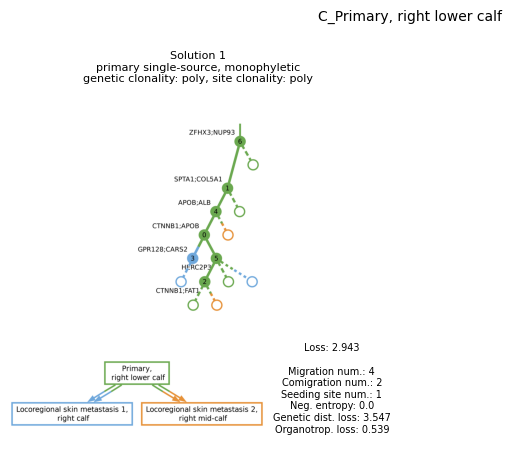

/data1/morrisq/divyak/projects/metient/tutorial/3_outputs/tmp_D_clustered_SNVs.tsv
Using organotropism frequencies {'Locoregional skin metastasis 1, right ankle': 0.42657342657342656, 'Locoregional skin metastasis 2, right leg': 0.42657342657342656, 'Lymph node metastasis, right groin': 0.14685314685314685}
Organotropism frequencies: tensor([0.00, 0.15, 0.43, 0.43])
Tumor samples: ['Primary, right ankle', 'Lymph node metastasis, right groin', 'Locoregional skin metastasis 1, right ankle', 'Locoregional skin metastasis 2, right leg']
Input tree has 3 nodes.


  3%|▎         | 149/4600 [00:00<00:19, 227.28it/s]

Number of fixed nodes: 2, number of unknown nodes: 2


100%|█████████▉| 4588/4600 [00:18<00:00, 252.30it/s]

Number of final solutions: 2
D_Primary, right ankle


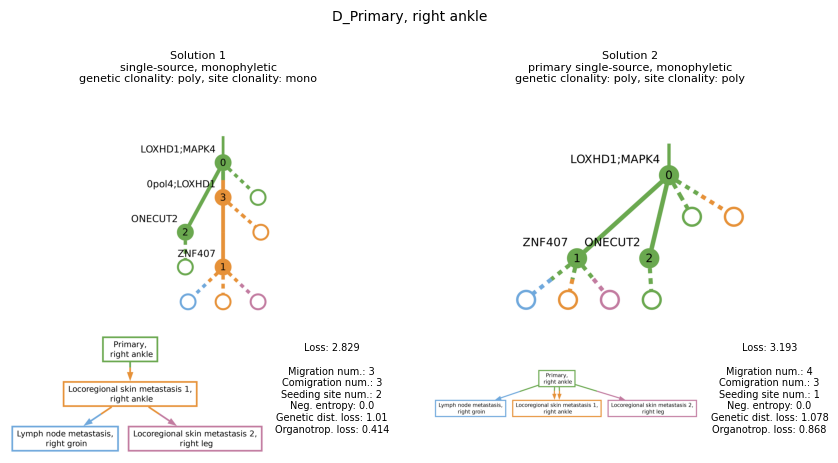

/data1/morrisq/divyak/projects/metient/tutorial/3_outputs/tmp_E_clustered_SNVs.tsv
Using organotropism frequencies {'Locoregional skin metastasis 1, left heel': 0.29901960784313725, 'Locoregional skin metastasis 2, left heel': 0.29901960784313725, 'Locoregional skin metastasis 3, left heel': 0.29901960784313725, 'Lymph node metastasis, left groin': 0.10294117647058823}
Organotropism frequencies: tensor([0.00, 0.30, 0.30, 0.10, 0.30])
Tumor samples: ['Primary, left heel', 'Locoregional skin metastasis 1, left heel', 'Locoregional skin metastasis 2, left heel', 'Lymph node metastasis, left groin', 'Locoregional skin metastasis 3, left heel']
Input tree has 7 nodes.


  3%|▎         | 120/4600 [00:00<00:31, 141.41it/s]

Number of fixed nodes: 6, number of unknown nodes: 3


100%|█████████▉| 4586/4600 [00:26<00:00, 177.92it/s]

Number of final solutions: 1
E_Primary, left heel


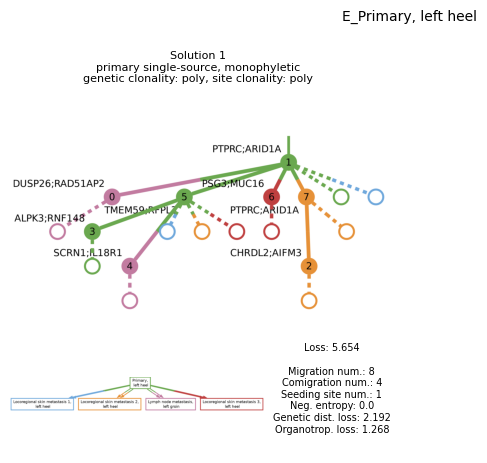

/data1/morrisq/divyak/projects/metient/tutorial/3_outputs/tmp_F_clustered_SNVs.tsv
Using organotropism frequencies {'Locoregional skin metastasis, left ear': 0.42657342657342656, 'Distant skin metastasis, back': 0.42657342657342656, 'Lymph node metastasis, left cervical node': 0.14685314685314685}
Organotropism frequencies: tensor([0.00, 0.15, 0.43, 0.43])
Tumor samples: ['Primary, left ear', 'Lymph node metastasis, left cervical node', 'Locoregional skin metastasis, left ear', 'Distant skin metastasis, back']
Input tree has 9 nodes.


  3%|▎         | 122/4600 [00:00<00:32, 135.71it/s]

Number of fixed nodes: 2, number of unknown nodes: 8


100%|█████████▉| 4591/4600 [00:28<00:00, 167.73it/s]

Number of final solutions: 1
F_Primary, left ear


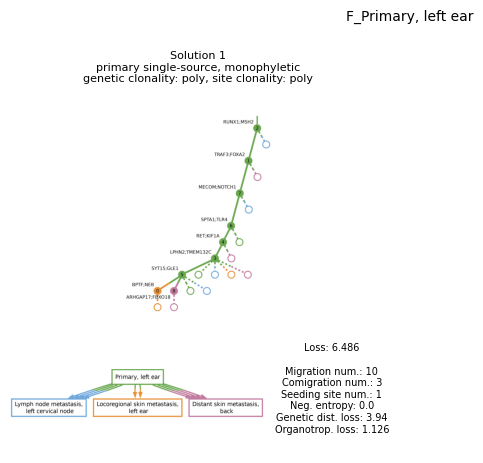

/data1/morrisq/divyak/projects/metient/tutorial/3_outputs/tmp_G_clustered_SNVs.tsv
Using organotropism frequencies {'Lung metastasis': 0.6534090909090909, 'Locoregional skin metastasis, axilla': 0.3465909090909091}
Organotropism frequencies: tensor([0.00, 0.65, 0.35])
Tumor samples: ['Primary, right forearm', 'Lung metastasis', 'Locoregional skin metastasis, axilla']
Input tree has 4 nodes.


  3%|▎         | 145/4600 [00:00<00:20, 218.80it/s]

Number of fixed nodes: 2, number of unknown nodes: 2


100%|█████████▉| 4596/4600 [00:19<00:00, 240.08it/s]

Number of final solutions: 1
G_Primary, right forearm


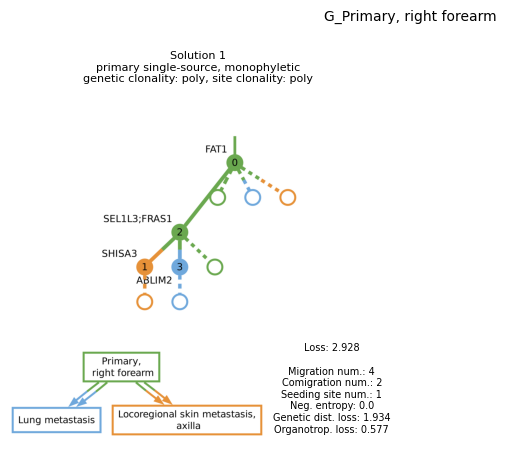

In [4]:
patients = ["A", "B", "C", "D", "E", "F", "G"]

print_config = met.PrintConfig(visualize=True, verbose=False, k_best_trees=10)
# Use weights which have been calibrated to real data
weights = met.Weights.pancancer_genetic_organotropism_uniform_weighting()
# Optionally, add a small genetic distance and/or organotropism penalty to break ties between solutions with equal parsimony metrics
weights.organotrop = 0.01
weights.gen_dist = 0.01

for patient, O in zip(patients, Os):
    clone_tree_fn = os.path.join(input_dir, f"{patient}_tree.txt")
    ref_var_fn = os.path.join(input_dir, f"{patient}_SNVs.tsv")
    met.evaluate(clone_tree_fn, ref_var_fn, weights, print_config, output_dir, patient, O=O, solve_polytomies=True)


## Step 3: Use the pickle file outputs for downstream analysis

### In addition to the visualizations that Metient provides, we also save pkl.gz files for each Metient run that contain all the results of the run.

In [5]:
import gzip
import pickle

with gzip.open(os.path.join(output_dir, "D_Primary, right ankle.pkl.gz") ,"rb") as f:
    pckl = pickle.load(f)
print(pckl.keys())

# Get classifications for clonality and phyleticity, weighted by probability of each solution
print("Overall genetic clonality:", met.weighted_genetic_clonality(pckl))
print("Overall site clonality:", met.weighted_site_clonality(pckl))
print("Overall phyleticity:", met.weighted_phyleticity(pckl))

print("\nSolution probabilities:", pckl['probabilities'])

# Look at individual solutions:
for idx in range(len(pckl['node_labels'])):
    print("\n===============================")
    print("Solution {idx} probability: {prob:.4f}".format(idx=idx, prob=pckl['probabilities'][idx]))
    # V is the best node labeling
    V = pckl['node_labels'][idx]
    # A is the adjacency matrix that is the input clone tree + inferred witness nodes + polytomy resolved nodes
    parents = pckl['parents'][idx]
    A = met.adjacency_matrix_from_parents(parents)
    # G represents the migration graph
    G = met.migration_graph(V, A)
    print("\nMigration graph:\n", G)

    node_info = pckl['node_info'][idx]

    # Show other information about this inferred migration history
    print("\nSeeding pattern:", met.seeding_pattern(V, A))
    print("Seeding clusters:", met.seeding_clusters(V, A,node_info))
    print("Phyleticity:", met.phyleticity(V, A, node_info))
    print("Site clonality:", met.site_clonality(V, A))
    print("Genetic clonality:", met.genetic_clonality(V, A,node_info))

dict_keys(['node_labels', 'losses', 'node_info', 'parents', 'anatomical_sites', 'loss_info', 'primary_site', 'probabilities', 'soft_labeling', 'genetic_distances', 'observed_proportions'])
Overall genetic clonality: polyclonal
Overall site clonality: monoclonal
Overall phyleticity: monophyletic

Solution probabilities: [0.88079707 0.11920293]

Solution 0 probability: 0.8808

Migration graph:
 tensor([[0., 0., 1., 0.],
        [0., 0., 0., 0.],
        [0., 1., 0., 1.],
        [0., 0., 0., 0.]])

Seeding pattern: single-source
Seeding clusters: [0, 1]
Phyleticity: monophyletic
Site clonality: monoclonal
Genetic clonality: polyclonal

Solution 1 probability: 0.1192

Migration graph:
 tensor([[0., 1., 2., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Seeding pattern: primary single-source
Seeding clusters: [0, 1]
Phyleticity: monophyletic
Site clonality: polyclonal
Genetic clonality: polyclonal


100%|██████████| 4600/4600 [00:34<00:00, 240.08it/s]